<a href="https://colab.research.google.com/github/ErasmoR/Erasmor/blob/master/Copy_of_proy_integrador2_empleo_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA, probabilidad de inserción laboral Panamá

In [ ]:
!pip install -q pandas matplotlib seaborn pyreadstat
!pip install -q itables
!pip install linearmodels

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
import warnings
from itables import show
import statsmodels.api as sm

warnings.filterwarnings('ignore')

In [ ]:
# Subir archivo manualmente

from google.colab import files
uploaded = files.upload()

Saving 240322base de datos completa.sav to 240322base de datos completa (1).sav


In [ ]:
# Carga de la base de datos
df, meta = pyreadstat.read_sav("240322base de datos completa.sav")

# Exploración de variables y tamaño de dataset

In [ ]:
print(df.shape)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df.head(10)

Al realizar la carga del dataset, se obtuvieron 42925 registros y 207 variables

In [ ]:
print("\nInformación general del dataset")
df.info()


Información general del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42925 entries, 0 to 42924
Columns: 207 entries, D_R to h5a_ot_raz
dtypes: float64(110), object(97)
memory usage: 67.8+ MB


In [ ]:
columnas = list(df.columns)

for columna in df.columns:
  print(f"{columna}: {df[columna].dtype}")

D_R: object
llave_sec: float64
provincia: object
prov: object
unidad: object
cuest: object
hogar: object
nper: object
Jefe_de_hogar: float64
p1a_otro: object
Sexo: float64
Edad: float64
Seguro_Social: float64
p4a_ss_fic: float64
p4b: float64
p4c: float64
p4c_otro: object
Persona_con_dispacidad: float64
tipo_de_dispacidad: float64
p4d: float64
p4d_otro: object
p4f: float64
p4f_otro: object
Estado_civil: float64
p4o_pais: object
p4p_cuando: object
p4p_anio: float64
Fondo_de_pensiones_privado: float64
Asiste_a_la_escuela: float64
Tipo_de_educación: float64
p5_asistio: float64
p5a: float64
p5a_otro_m: object
p5b: float64
Grado_alcanzado: float64
Sabe_leer_y_escribir: float64
p7_titulo: float64
p7b: float64
p7b_cuanto: float64
p8_16: float64
p11_meses: object
p08_16b_ot: object
p17: float64
p18: float64
p18a: object
p19: float64
p20: float64
p21: float64
p21a_otro: object
p22a: float64
p22b: float64
p22c: float64
p23: float64
p24: float64
p25: float64
p25_otro: object
p26: object
Dónde_trab

Se realiza una exploración de estas variables y sus tipos de datos para tener una idea de las que podemos utilizar en los modelos

In [ ]:
df_modelo = df.copy()

# Selección de variables a utilizar en el modelo

Salario por Hora

In [ ]:
# Copia del dataset
df = df.copy()

In [ ]:
# Variables del hogar
id_hogar = ['llave_sec', 'provincia', 'prov', 'unidad', 'cuest', 'hogar']

# Eliminar columnas de hogar si ya existen en df_modelo
cols_hogar = ['ingreso_hogar', 'personas', 'niños', 'adultos_mayores', 'dependencia', 'ingreso_per_capita']
df_modelo = df_modelo.drop(columns=cols_hogar, errors='ignore')

# Variables auxiliares
df_modelo['niño'] = (df_modelo['Edad'] < 15).astype(int)
df_modelo['adulto_mayor'] = (df_modelo['Edad'] >= 65).astype(int)

# Reemplazar nulos por 0
df_modelo['Salario_efectivo_empleado'] = df_modelo['Salario_efectivo_empleado'].fillna(0)
df_modelo['Salario_efectivo_independiente'] = df_modelo['Salario_efectivo_independiente'].fillna(0)

# Crear ingreso total individual
df_modelo['ingreso_total_individual'] = (
    df_modelo['Salario_efectivo_empleado'] + df_modelo['Salario_efectivo_independiente']
)

# Dataset agregado por hogar
hogar = df_modelo.groupby(id_hogar).agg(
    ingreso_hogar=('ingreso_total_individual', 'sum'),
    personas=('Edad', 'count'),
    niños=('niño', 'sum'),
    adultos_mayores=('adulto_mayor', 'sum')
).reset_index()

# Indicadores del hogar
hogar['dependencia'] = (hogar['niños'] + hogar['adultos_mayores']) / hogar['personas']
hogar['ingreso_per_capita'] = hogar['ingreso_hogar'] / hogar['personas']


# Unir variables del hogar al dataset individual
df_modelo = df_modelo.merge(hogar, on=id_hogar, how='left')

# Seleccionar variables finales
columnas_finales = id_hogar + [
    'Sexo',
    'Edad',
    'Jefe_de_hogar',
    'Asiste_a_la_escuela',
    'Grado_alcanzado',
    'ocu_des',
    'Salario_efectivo_empleado',
    'Salario_efectivo_independiente',
    'Recibe_jubilacion_pension',
    'Uso_internet_últimos_6_meses',
    'ingreso_hogar',
    'personas',
    'niños',
    'adultos_mayores',
    'dependencia',
    'ingreso_per_capita'
]

df_modelo_final = df_modelo[columnas_finales].copy()

df_modelo_final.head(6)


,llave_sec,provincia,prov,unidad,cuest,hogar,Sexo,Edad,Jefe_de_hogar,Asiste_a_la_escuela,Grado_alcanzado,ocu_des,Salario_efectivo_empleado,Salario_efectivo_independiente,Recibe_jubilacion_pension,Uso_internet_últimos_6_meses,ingreso_hogar,personas,niños,adultos_mayores,dependencia,ingreso_per_capita
0,1.0,01,01,001,01,1,1.0,44.0,1.0,2.0,53.0,Ocupados,0.0,1516.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333
1,1.0,01,01,001,01,1,2.0,21.0,2.0,2.0,36.0,Ocupados,600.0,0.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333
2,1.0,01,01,001,01,1,1.0,4.0,3.0,2.0,1.0,,0.0,0.0,0.0,NaN,2116.0,3,1,0,0.333333,705.333333
3,2.0,01,01,001,02,1,2.0,22.0,1.0,2.0,36.0,Ocupados,700.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667
4,2.0,01,01,001,02,1,1.0,26.0,2.0,2.0,36.0,Ocupados,850.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667
5,2.0,01,01,001,02,1,1.0,3.0,3.0,NaN,NaN,,0.0,0.0,0.0,NaN,1550.0,3,1,0,0.333333,516.666667


In [ ]:
# Borrar
df.shape

(42925, 212)

In [ ]:
# Borrar
df_modelo.shape

(42925, 222)

In [ ]:
# Borrar
df_modelo_final.shape

(42925, 24)

In [ ]:
# Borrar
# Agrupar edades sin crear nueva columna
grupos = pd.cut(
    df_modelo_final['Edad'],
    bins=[0, 17, 65, 120],
    labels=['< 18 años', '18 - 65 años', '> 65 años']
)

# Conteo
conteo = grupos.value_counts().sort_index()

# Porcentaje
porcentaje = grupos.value_counts(normalize=True).sort_index() * 100

# Resultado
distribucion = pd.DataFrame({
    'Conteo': conteo,
    'Porcentaje (%)': porcentaje.round(2)
})

distribucion

,Conteo,Porcentaje (%)
Edad,,
< 18 años,13259,31.37
18 - 65 años,24669,58.37
> 65 años,4337,10.26


In [ ]:
#Transformación de variables númericas que representan categorías

df_modelo_final['Sexo'] = df_modelo_final['Sexo'].astype('category')
df_modelo_final['Jefe_de_hogar'] = df_modelo_final['Jefe_de_hogar'].astype('category')
df_modelo_final['Asiste_a_la_escuela'] = df_modelo_final['Asiste_a_la_escuela'].astype('category')
df_modelo_final['Grado_alcanzado'] = df_modelo_final['Grado_alcanzado'].astype('category')



In [ ]:
print(df_modelo_final.shape)

In [ ]:
print("\nEstadísticas descriptivas variables numéricas")
print(df_modelo_final.describe())

print("\nEstadísticas variables categóricas")
print(df_modelo_final.describe(include=['object', 'category']))



In [ ]:
# =========================================
# Distribución de variables categóricas
# =========================================

variables_categoricas = [
    'Sexo',
    'Jefe_de_hogar',
    'Grado_alcanzado',
    'provincia',
    'Uso_internet_últimos_6_meses'
]

for var in variables_categoricas:

    print("\n==============================")
    print(f"Distribución de {var}")

    freq = df_modelo_final[var].value_counts()
    porcentaje = df_modelo_final[var].value_counts(normalize=True)*100

    tabla = pd.concat([freq, porcentaje], axis=1)
    tabla.columns = ['Frecuencia','Porcentaje']

    print(tabla)


Distribución de Sexo
      Frecuencia  Porcentaje
Sexo                        
2.0        21694   50.539313
1.0        21231   49.460687

Distribución de Jefe_de_hogar
               Frecuencia  Porcentaje
Jefe_de_hogar                        
3.0                 15963   37.188119
1.0                 12031   28.027956
4.0                  7680   17.891672
2.0                  6858   15.976704
6.0                   315    0.733838
5.0                    78    0.181712

Distribución de Grado_alcanzado
                 Frecuencia  Porcentaje
Grado_alcanzado                        
36.0                   6585   16.423085
16.0                   6429   16.034018
33.0                   3325    8.292598
1.0                    2619    6.531824
32.0                   1835    4.576516
13.0                   1642    4.095172
35.0                   1544    3.850758
31.0                   1478    3.686153
56.0                   1444    3.601357
15.0                   1404    3.501596
34.0          

In [ ]:
# Verificación de valores nulos por columna (en porcentaje)
porcentaje_nulos = (df_modelo_final.isnull().sum() / len(df_modelo_final)) * 100
print(porcentaje_nulos)

llave_sec                          0.000000
provincia                          0.000000
prov                               0.000000
unidad                             0.000000
cuest                              0.000000
hogar                              0.000000
Sexo                               0.000000
Edad                               0.000000
Jefe_de_hogar                      0.000000
Asiste_a_la_escuela                6.590565
Grado_alcanzado                    6.590565
ocu_des                            0.000000
Salario_efectivo_empleado          0.000000
Salario_efectivo_independiente     0.000000
Recibe_jubilacion_pension          0.000000
Uso_internet_últimos_6_meses      17.232382
ingreso_hogar                      0.000000
personas                           0.000000
niños                              0.000000
adultos_mayores                    0.000000
dependencia                        0.000000
ingreso_per_capita                 0.000000
dtype: float64


Se realiza una análisis preliminar de los valores nulos y su porcentaje

<Axes: >

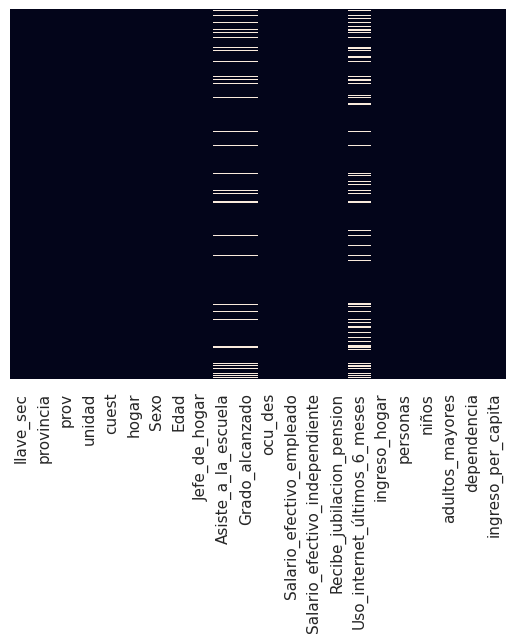

In [ ]:
# Distribución de nulos por medio del color blanco
sns.heatmap(df_modelo_final.isnull(), cbar=False, yticklabels = False)

Para visualizar los valores nulos, nos ayudamos con este mapa de calor, marcándolos en blanco

# Recodificación de variables para mejor entendimiento

Se crean diccionarios para transformar los valores numéricos a sus respectivas categorías.

In [ ]:
dicc_sexo = {
    1: 'Masculino',
    2: 'Femenino',
}

df_modelo_final.loc[:, 'Sexo'] = df_modelo_final['Sexo'].replace(dicc_sexo).astype(str)

In [ ]:
dicc_jefe_h = {
    1: 'Jefe o jefa',
    2: 'Conyugue',
    3: 'Hijo o hija',
    4: 'Otro pariente',
    5: 'Servicio domestico'
}

df_modelo_final.loc[:, 'Jefe_de_hogar'] = df_modelo_final['Jefe_de_hogar'].replace(dicc_jefe_h).astype(str)

In [ ]:
dicc_provincia = {
    '01': 'Bocas del Toro',
    '02': 'Coclé',
    '03': 'Colón',
    '04': 'Chiriquí',
    '05': 'Darién',
    '06': 'Herrera',
    '07': 'Los Santos',
    '08': 'Panamá',
    '09': 'Veraguas',
    '10': 'Comarca Guna Yala',
    '11': 'Comarca Emberá-Wounaan',
    '12': 'Comarca Ngäbe-Buglé',
    '13': 'Panamá Oeste'
}

df_modelo_final.loc[:, 'provincia'] = df_modelo_final['provincia'].replace(dicc_provincia)

In [ ]:
dicc_nivel_edu = {
    1: 'Ningun grado',
    2: 'Prekínder o prejardín',
    3: 'Kínder o jardín',
    4: 'Enseñanza especial',
    11: 'Primaria',
    12: 'Primaria',
    13: 'Primaria',
    14: 'Primaria',
    15: 'Primaria',
    16: 'Primaria',
    21: 'Vocacional',
    22: 'Vocacional',
    23: 'Vocacional',
    31: 'Primer ciclo premedia',
    32: 'Primer ciclo premedia',
    33: 'Primer ciclo premedia',
    34: 'Segundo ciclo media',
    35: 'Segundo ciclo media',
    36: 'Segundo ciclo media',
    41: 'Superior no universitaria',
    42: 'Superior no universitaria',
    51: 'Superior universitario',
    52: 'Superior universitario',
    53: 'Superior universitario',
    54: 'Superior universitario',
    55: 'Superior universitario',
    56: 'Superior universitario',
    61: 'Especialidad postgrado',
    71: 'Maestria',
    72: 'Maestria',
    81: 'Doctorado',
    82: 'Doctorado',
    83: 'Doctorado',
    84: 'Doctorado',
    'nan': 'Menores de 4 años',
}

df_modelo_final.loc[:, 'Grado_alcanzado'] = df_modelo_final['Grado_alcanzado'].replace(dicc_nivel_edu).astype(str)

Utilizamos una revisión general después de haber aplicado los diccionarios

In [ ]:
df_modelo_final.head(10)

,llave_sec,provincia,prov,unidad,cuest,hogar,Sexo,Edad,Jefe_de_hogar,Asiste_a_la_escuela,Grado_alcanzado,ocu_des,Salario_efectivo_empleado,Salario_efectivo_independiente,Recibe_jubilacion_pension,Uso_internet_últimos_6_meses,ingreso_hogar,personas,niños,adultos_mayores,dependencia,ingreso_per_capita
0,1.0,Bocas del Toro,01,001,01,1,Masculino,44.0,Jefe o jefa,2.0,Superior universitario,Ocupados,0.0,1516.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333
1,1.0,Bocas del Toro,01,001,01,1,Femenino,21.0,Conyugue,2.0,Segundo ciclo media,Ocupados,600.0,0.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333
2,1.0,Bocas del Toro,01,001,01,1,Masculino,4.0,Hijo o hija,2.0,Ningun grado,,0.0,0.0,0.0,NaN,2116.0,3,1,0,0.333333,705.333333
3,2.0,Bocas del Toro,01,001,02,1,Femenino,22.0,Jefe o jefa,2.0,Segundo ciclo media,Ocupados,700.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667
4,2.0,Bocas del Toro,01,001,02,1,Masculino,26.0,Conyugue,2.0,Segundo ciclo media,Ocupados,850.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667
5,2.0,Bocas del Toro,01,001,02,1,Masculino,3.0,Hijo o hija,NaN,nan,,0.0,0.0,0.0,NaN,1550.0,3,1,0,0.333333,516.666667
6,3.0,Bocas del Toro,01,001,03,1,Femenino,34.0,Jefe o jefa,2.0,Segundo ciclo media,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000
7,3.0,Bocas del Toro,01,001,03,1,Masculino,43.0,Conyugue,2.0,Superior universitario,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000
8,3.0,Bocas del Toro,01,001,03,1,Femenino,16.0,Hijo o hija,1.0,Segundo ciclo media,,0.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000
9,3.0,Bocas del Toro,01,001,03,1,Femenino,56.0,Otro pariente,2.0,Segundo ciclo media,Ocupados,526.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000


In [ ]:
df_modelo_final['ocu_des'].unique()

array(['Ocupados', '', 'Desocupados'], dtype=object)

In [ ]:
df_mayores_18 = df_modelo_final[df_modelo_final['Edad'] >= 18]


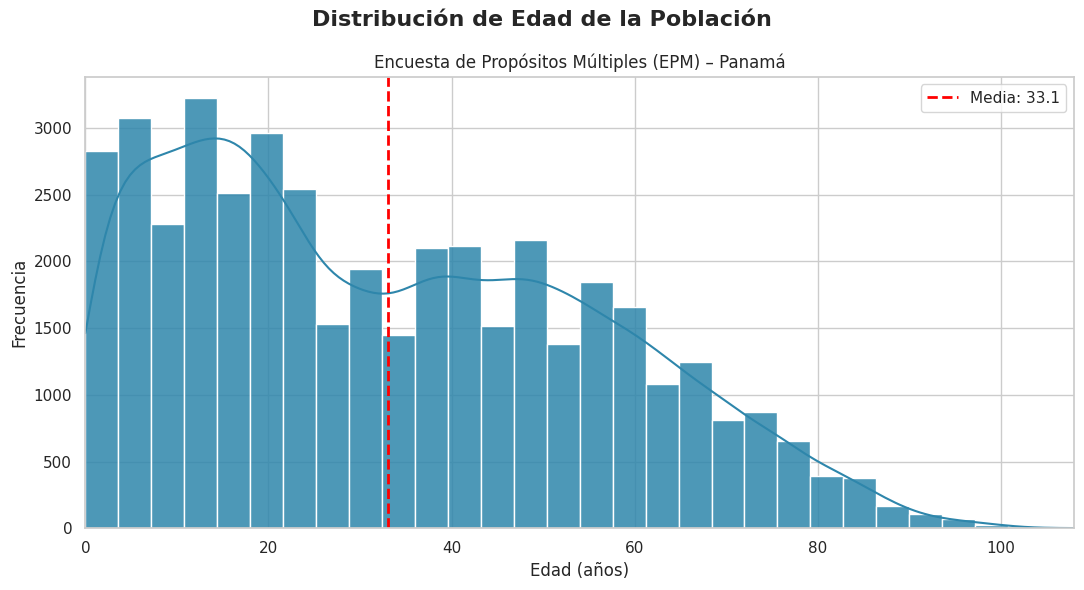

In [ ]:
# Distribución de Edad en la encuesta

sns.set_theme(style="whitegrid")

plt.figure(figsize=(11,6))

sns.histplot(
    data=df_modelo_final,
    x='Edad',
    bins=30,
    kde=True,
    color='#2E86AB',
    edgecolor='white',
    alpha=0.85
)

# Línea de media
media_edad = df_modelo_final['Edad'].mean()
plt.axvline(media_edad, color='red', linestyle='--', linewidth=2,
            label=f'Media: {media_edad:.1f}')

plt.suptitle('Distribución de Edad de la Población', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=12)

plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xlim(df_modelo_final['Edad'].min(), df_modelo_final['Edad'].max())

plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
# Reclasificación de niveles educativos
def clasificar_educacion(x):
    if x in ['Ningun grado', 'Prekínder o prejardín', 'Kínder o jardín', 'Menores de 4 años']:
        return 'Inicial / Sin educación'
    elif x == 'Primaria':
        return 'Primaria'
    elif x in ['Primer ciclo premedia', 'Segundo ciclo media']:
        return 'Media'
    elif x in ['Superior universitario', 'Superior no universitaria']:
        return 'Superior'
    elif x in ['Maestria', 'Especialidad postgrado', 'Doctorado']:
        return 'Postgrado'
    elif x == 'Vocacional':
        return 'Técnico'
    else:
        return 'Otros'

df_mayores_18['educacion_grupo'] = df_mayores_18['Grado_alcanzado'].apply(clasificar_educacion)

<Figure size 1100x600 with 0 Axes>

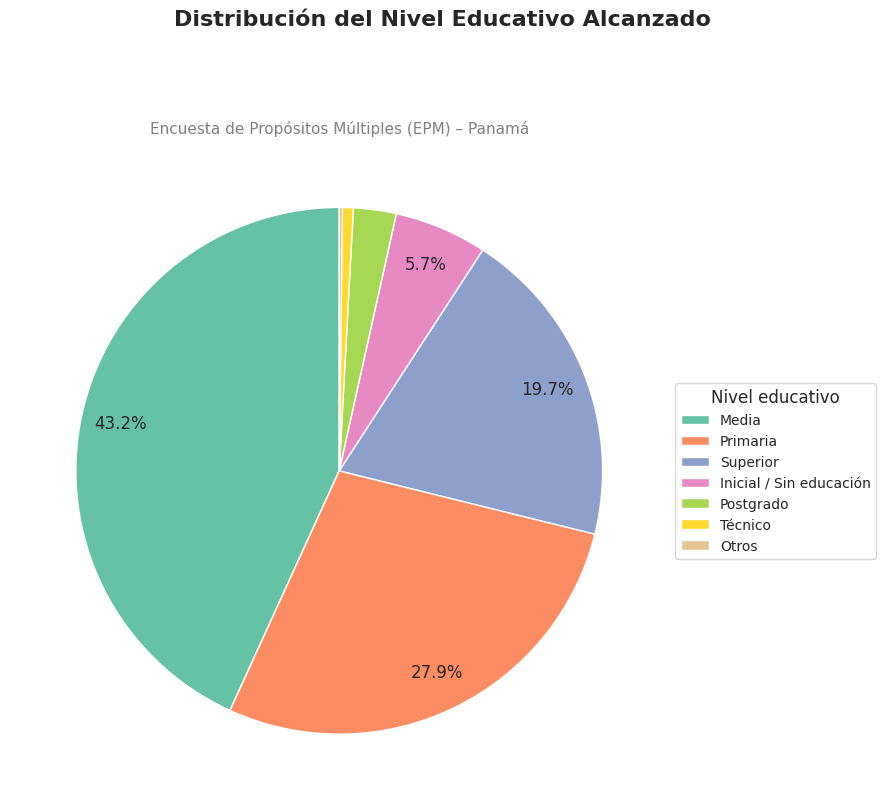

In [ ]:
# Gráfica del nivel educativo alcanzado
sns.set_theme(style="white")

plt.figure(figsize=(11,6))

# Conteo y orden
conteo = df_mayores_18['educacion_grupo'].value_counts()
orden = conteo.index


plt.figure(figsize=(9,9))

wedges, texts, autotexts = plt.pie(
    conteo,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors = sns.color_palette("Set2", len(conteo)),
    pctdistance=0.85,
    labeldistance=1.1,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
)

for i, (wedge, pct) in enumerate(zip(wedges, conteo / conteo.sum() * 100)):

    if pct < 5:  # umbral para mover afuera

        ang = (wedge.theta2 + wedge.theta1) / 2.
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))

        autotexts[i].set_visible(False)  # oculta el % interno

plt.legend(
    conteo.index,
    title="Nivel educativo",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

plt.suptitle('Distribución del Nivel Educativo Alcanzado', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=11, color='gray')

plt.tight_layout()
plt.show()

# Condición laboral

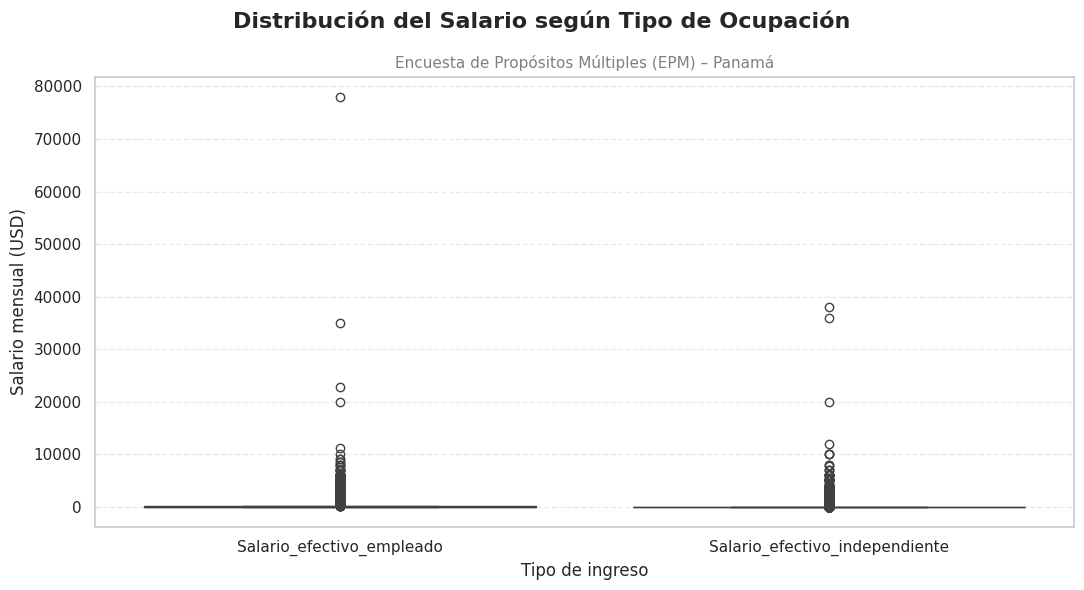

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(11,6))

sns.boxplot(
    data=df_modelo_final[['Salario_efectivo_empleado',
                          'Salario_efectivo_independiente']],
    palette=['#2E86AB', '#F39C12'],
    showfliers=True
)

plt.suptitle('Distribución del Salario según Tipo de Ocupación', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=11, color='gray')

plt.xlabel('Tipo de ingreso')
plt.ylabel('Salario mensual (USD)')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
df_modelo_final['Grado_alcanzado'] = df_modelo_final['Grado_alcanzado'].fillna('No aplica')
df_modelo_final['Uso_internet_últimos_6_meses'] = df_modelo_final['Uso_internet_últimos_6_meses'].fillna('Sin data')

In [ ]:
# Variabla de condición laboral

df_modelo_final['condicion_laboral'] = np.select(
    [
        df_modelo_final['Salario_efectivo_empleado'] > 0,
        df_modelo_final['Salario_efectivo_independiente'] > 0,
        df_modelo_final['Recibe_jubilacion_pension'] == 1,
        (df_modelo_final['ocu_des'] == 'Desocupados') &
        (df_modelo_final['Asiste_a_la_escuela'] == 2),
         df_modelo_final['Asiste_a_la_escuela'] == 1
    ],
    [
        'Empleado',
        'Independiente',
        'Jubilado / pensionado',
        'Desocupado que no estudia',
        'Estudiante'
    ],
    default='Otro'
)


In [ ]:
df_pet = df_modelo_final[
    (df_modelo_final['Edad'] >= 18) &
    (df_modelo_final['Edad'] <= 64)
]

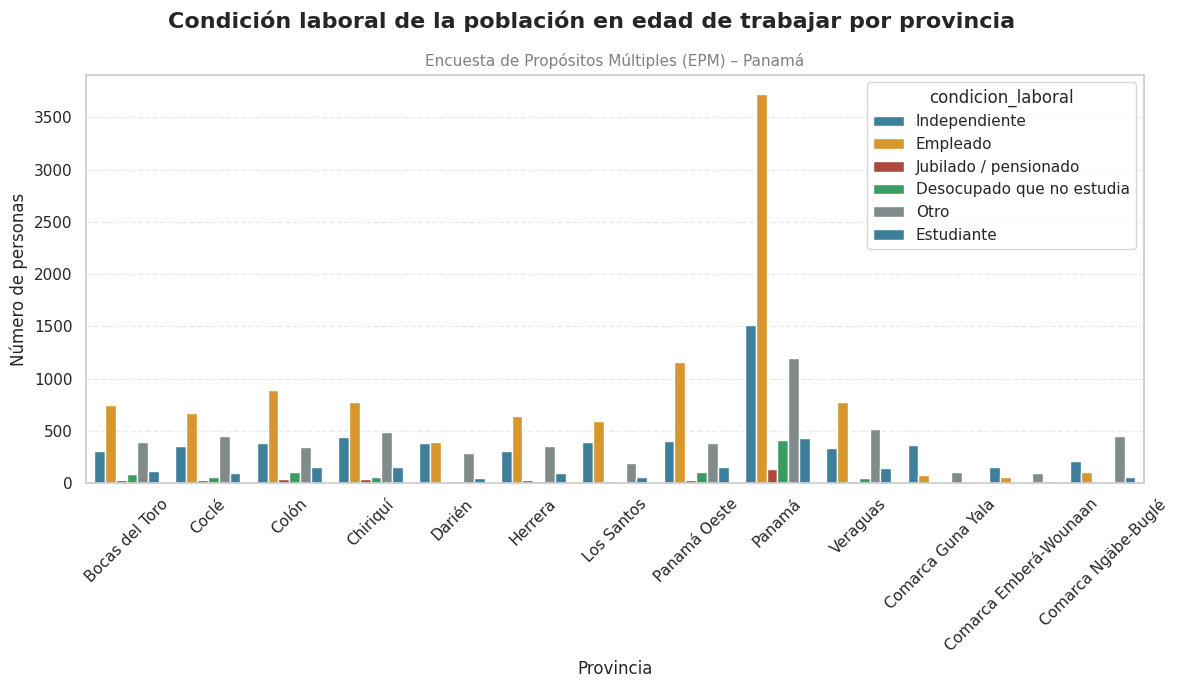

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,7))

sns.countplot(
    data=df_pet,
    x='provincia',
    hue='condicion_laboral',
    palette=['#2E86AB','#F39C12','#C0392B', '#27AE60', '#7F8C8D']
)

plt.suptitle('Condición laboral de la población en edad de trabajar por provincia', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=11, color='gray')

plt.xlabel('Provincia')
plt.ylabel('Número de personas')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

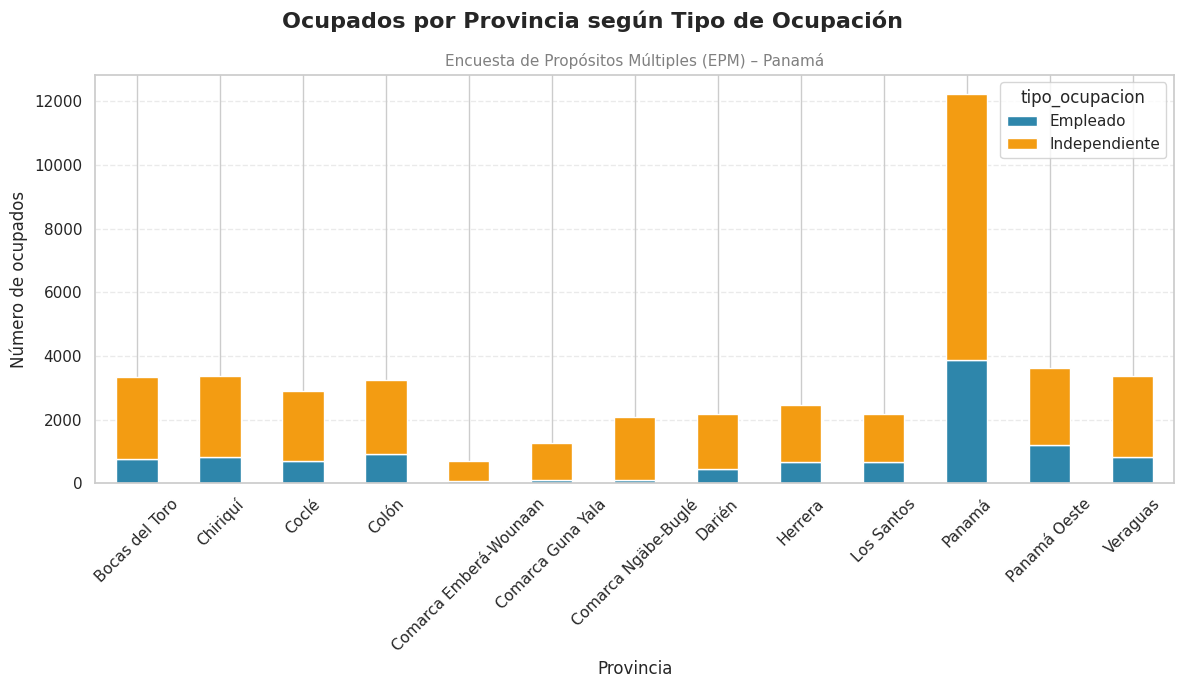

In [ ]:
sns.set_theme(style="whitegrid")

# Crear variable tipo de ocupación
df_modelo_final['tipo_ocupacion'] = df_modelo_final.apply(
    lambda x: 'Empleado' if x['Salario_efectivo_empleado'] > 0 else 'Independiente',
    axis=1
)

tabla = pd.crosstab(df_modelo_final['provincia'], df_modelo_final['tipo_ocupacion'])

tabla.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    color=['#2E86AB','#F39C12']
)

plt.suptitle('Ocupados por Provincia según Tipo de Ocupación', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=11, color='gray')

plt.xlabel('Provincia')
plt.ylabel('Número de ocupados')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# Distribución dependencia del hogar
# =========================================

plt.figure(figsize=(11,6))

sns.histplot(
    df_modelo_final['dependencia'],
    bins=30,
    kde=True,
    color='#F39C12'
)

plt.suptitle('Distribución del índice de dependencia del hogar', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=11)

plt.xlabel('Dependencia del hogar')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# Edad vs ingreso per capita
# =========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_modelo_final,
    x='Edad',
    y='ingreso_per_capita',
    alpha=0.4
)

plt.title("Relación entre edad e ingreso per cápita")

plt.xlabel("Edad")
plt.ylabel("ingreso_per_capita")

plt.show()

In [ ]:
# =========================================
# Educación vs ingreso
# =========================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_mayores_18,
    x='educacion_grupo',
    y='ingreso_per_capita'
)

plt.title("Ingreso per cápita según nivel educativo")

plt.xlabel("Nivel educativo")
plt.ylabel("Ingreso per cápita")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# =========================================
# Ingreso promedio por provincia
# =========================================

ingreso_provincia = df_modelo_final.groupby('provincia')['ingreso_per_capita'].mean().sort_values()

plt.figure(figsize=(10,7))

ingreso_provincia.plot(
    kind='barh'
)

plt.title("Ingreso per cápita promedio por provincia")

plt.xlabel("Ingreso per cápita promedio")

plt.show()

In [ ]:
# =========================================
# Población en edad de trabajar
# =========================================

df_pet = df_modelo_final[
    (df_modelo_final['Edad'] >= 18) &
    (df_modelo_final['Edad'] <= 64)
]

In [ ]:
# =========================================
# Condición laboral por sexo
# =========================================

plt.figure(figsize=(11,6))

sns.countplot(
    data=df_pet,
    x='condicion_laboral',
    hue='Sexo'
)

plt.title("Condición laboral por sexo")

plt.xlabel("Condición laboral")
plt.ylabel("Número de personas")

plt.xticks(rotation=30)

plt.show()

In [ ]:
# =========================================
# Correlación entre variables numéricas
# =========================================

variables_numericas = [
    'Edad',
    #'Sexo',
    #'Grado_alcanzado',
    'Salario_efectivo_empleado',
    'Salario_efectivo_independiente'
]

corr = df_modelo_final[variables_numericas].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Matriz de correlación de variables numéricas")

plt.show()

# Modelo Mincer

In [ ]:
# Función para calcular años de educación basado en el grado de educación alcanzado
def calcular_anios_educacion(codigo):
    try:
        codigo = int(codigo)

        # Sin educación o preescolar
        if codigo <= 10:
            return 0

        # Primaria (11–16 → 1 a 6)
        elif 11 <= codigo <= 16:
            return codigo - 10

        # Vocacional (21–23 → asumimos 7–9)
        elif 21 <= codigo <= 23:
            return codigo - 14  # 7,8,9

        # Premedia (31–33 → 7–9)
        elif 31 <= codigo <= 33:
            return codigo - 24

        # Media (34–36 → 10–12)
        elif 34 <= codigo <= 36:
            return codigo - 24

        # Superior no universitaria (41–42 → 13–14)
        elif 41 <= codigo <= 42:
            return codigo - 28

        # Universidad (51–56 → 13–18)
        elif 51 <= codigo <= 56:
            return codigo - 38

        # Postgrado
        elif codigo == 61:
            return 19
        elif 71 <= codigo <= 72:
            return 20
        elif 81 <= codigo <= 84:
            return 22

        else:
            return 0

    except:
        return 0

In [ ]:
# =========================
# 1. Copia de trabajo
# =========================
df_mincer = df_modelo_final.copy()

# =========================
# 2. Filtrar ocupados
# =========================
df_mincer = df_mincer[df_mincer['ocu_des'] == 'Ocupados'].copy()

# =========================
# 3. Años de educación
# =========================
df_mincer['anios_educacion'] = df_mincer['Grado_alcanzado'].apply(
    lambda x: calcular_anios_educacion(x) if pd.notna(x) else np.nan
)

# =========================
# 4. Ingreso laboral total
# =========================
df_mincer['ingreso_laboral'] = (
    df_mincer['Salario_efectivo_empleado'].fillna(0) +
    df_mincer['Salario_efectivo_independiente'].fillna(0)
)

# =========================
# 5. Horas trabajadas
# =========================
df_mincer['Cuantas_horas_trabajó'] = pd.to_numeric(
    df['Cuantas_horas_trabajó'],
    errors='coerce'
)

df_mincer['horas_mensuales'] = df_mincer['Cuantas_horas_trabajó'] * 4.33

# =========================
# 6. Experiencia potencial
# =========================
df_mincer['experiencia'] = np.where(
    df_mincer['Edad'] >= 18,
    df_mincer['Edad'] - np.maximum(df_mincer['anios_educacion'] + 6, 18),
    np.nan
)

df_mincer['experiencia'] = df_mincer['experiencia'].clip(lower=0)
df_mincer['experiencia2'] = df_mincer['experiencia'] ** 2

# =========================
# 7. Salario por hora
# =========================
df_mincer['salario_hora'] = df_mincer['ingreso_laboral'] / df_mincer['horas_mensuales']

# =========================
# 8. Filtrar observaciones válidas
# =========================
df_mincer = df_mincer[
    (df_mincer['Edad'] >= 18) &
    (df_mincer['anios_educacion'].notna()) &
    (df_mincer['ingreso_laboral'] > 0) &
    (df_mincer['Cuantas_horas_trabajó'] > 0) &
    (df_mincer['horas_mensuales'] > 0)
].copy()

# =========================
# 9. Logaritmos
# =========================
df_mincer['ln_ingreso'] = np.log(df_mincer['ingreso_laboral'])
df_mincer['ln_salario_hora'] = np.log(df_mincer['salario_hora'])

# =========================
# 10. Limpieza final
# =========================
df_mincer = df_mincer.replace([np.inf, -np.inf], np.nan)

df_mincer = df_mincer.dropna(subset=[
    'anios_educacion',
    'experiencia',
    'experiencia2',
    'ingreso_laboral',
    'salario_hora',
    'ln_ingreso',
    'ln_salario_hora'
])

# =========================
# 11. Descriptivos
# =========================
display(df_mincer[[
    'Edad',
    'anios_educacion',
    'experiencia',
    'experiencia2',
    'ingreso_laboral',
    'Cuantas_horas_trabajó',
    'horas_mensuales',
    'salario_hora',
    'ln_ingreso',
    'ln_salario_hora'
]].describe())

In [ ]:
# Borrar
# Agrupar edades sin crear nueva columna
grupos = pd.cut(
    df_mincer['Edad'],
    bins=[0, 17, 65, 120],
    labels=['< 18 años', '18 - 65 años', '> 65 años']
)

# Conteo
conteo = grupos.value_counts().sort_index()

# Porcentaje
porcentaje = grupos.value_counts(normalize=True).sort_index() * 100

# Resultado
distribucion = pd.DataFrame({
    'Conteo': conteo,
    'Porcentaje (%)': porcentaje.round(2)
})

distribucion

,Conteo,Porcentaje (%)
Edad,,
< 18 años,0,0.00
18 - 65 años,16341,93.86
> 65 años,1069,6.14


In [ ]:
# Verificación de encabezado
df_mincer.head(10)

## Cálculo del modelo Mincer

In [ ]:
# Variables independientes
X = df_mincer[['anios_educacion', 'experiencia', 'experiencia2']]

# Agregar constante
X = sm.add_constant(X)

# Variable dependiente
y = df_mincer['ln_ingreso']

# Estimación OLS
modelo_mincer = sm.OLS(y, X).fit()

# Resultados
print(modelo_mincer.summary())

# Modelo Heckman

In [ ]:
# Importación de librería
from statsmodels.sandbox.regression.heckman import Heckman
from statsmodels.sandbox.regression.heckman import Heckman

ModuleNotFoundError: No module named 'statsmodels.sandbox.regression.heckman'

In [ ]:
# Preparación del dataset

In [ ]:
df_heckman = df_modelo[columnas_finales].copy()

In [ ]:
# Seguridad social
df_heckman['tiene_CSS'] = np.where(df_modelo['Seguro_Social'] == 6, 0, 1)


In [ ]:
##Variables de seguridad social
df['seguridad_social'] = (
    df['p72a'].fillna(0) +
    df['p72b'].fillna(0) +
    df['p72g1'].fillna(0) +
    df['p72g2'].fillna(0) +
    df['p72g3'].fillna(0) +
    df['p72g4'].fillna(0) +
    df['p72g5'].fillna(0) +
    df['p72g6'].fillna(0)
)

df_heckman['seguridad_social'] = df['seguridad_social']


In [ ]:
## Cómo construir variable: Ingreso no laboral
df_heckman['ingreso_no_laboral'] = (
    #df['seguridad_social'] +
    df['p72c1'].fillna(0) +
    df['p72c2'].fillna(0) +
    df['p72c3'].fillna(0) +
    df['p72c4'].fillna(0) +
    df['p72c5'].fillna(0) +
    df['p72c7'].fillna(0) +
    df['p72c8'].fillna(0) +
    df['p72f1'].fillna(0) +
    df['p72f2'].fillna(0) +
    df['p72f3'].fillna(0) +
    df['p72f4'].fillna(0)
)

df_heckman['ingreso_no_laboral'] = df['ingreso_no_laboral']


In [ ]:
# Variable Tipo de contrato
df_heckman['tipo_contrato'] = df['Tipo_de_contrato'].fillna(0)

# Recodificación según la ilo
df_heckman['tipo_contrato_eco'] = np.select(
    [
        df_heckman['tipo_contrato'].isin([1,4]),
        df_heckman['tipo_contrato'].isin([2,3]),
        df_heckman['tipo_contrato'] == 5
    ],
    [
        'Formal',
        'Temporal',
        'Informal'
    ],
    default='No especificado'
)

In [ ]:
# Variable tamaño de la empresa

# Limpiar la columna original (sin modificar df)
p29_clean = pd.to_numeric(df['p29'], errors='coerce')

# Añadir la columna categórica a df_heckman
df_heckman['tamano_empresa'] = p29_clean.map({
    1: 'Microempresa',
    2: 'Microempresa',
    3: 'Pequeña',
    4: 'Pequeña',
    5: 'Mediana_Grande'
}).fillna('Sin respuesta')

# Añadir la columna numérica para modelos, donde NaN → 0
df_heckman['tamano_empresa_rec'] = p29_clean.map({
    1: 1,
    2: 1,
    3: 2,
    4: 2,
    5: 3
}).fillna(0).astype(int)


In [ ]:
# Reclasificación en 7 sectores
# 1. Crear sector_7 dentro de df_modelo
col_rama = 'Actividad_económica'  # cambia este nombre si en df_modelo aparece distinto

df_modelo[col_rama] = pd.to_numeric(df_modelo[col_rama], errors='coerce')

def recodificar_sector_7(x):
    if pd.isna(x):
        return np.nan
    x = int(x)

    if x in [1, 2]:
        return 'Primario'
    elif x in [3, 4, 5]:
        return 'Manufactura y utilities'
    elif x == 6:
        return 'Construcción'
    elif x in [7, 8, 9]:
        return 'Comercio, transporte y turismo'
    elif x in [10, 11, 12, 13, 14]:
        return 'Servicios empresariales y financieros'
    elif x in [15, 16, 17]:
        return 'Sector público y social'
    elif x in [18, 19, 20, 21]:
        return 'Otros servicios y hogares'
    else:
        return np.nan

df_modelo['sector_7'] = df_modelo[col_rama].apply(recodificar_sector_7)

orden_sector = [
    'Comercio, transporte y turismo',
    'Primario',
    'Manufactura y utilities',
    'Construcción',
    'Servicios empresariales y financieros',
    'Sector público y social',
    'Otros servicios y hogares'
]

df_modelo['sector_7'] = pd.Categorical(
    df_modelo['sector_7'],
    categories=orden_sector,
    ordered=False
)

# 2. Agregar sector_7 a columnas_finales si no está
if 'sector_7' not in columnas_finales:
    columnas_finales = columnas_finales + ['sector_7']

# 3. Recrear df_heckman
df_heckman = df_modelo[columnas_finales].copy()

# 4. Verificar
print(df_heckman[['sector_7']].head())
print(df_heckman['sector_7'].value_counts(dropna=False))
print(round(df_heckman['sector_7'].value_counts(normalize=True, dropna=False) * 100, 2))

                         sector_7
0  Comercio, transporte y turismo
1  Comercio, transporte y turismo
2                             NaN
3  Comercio, transporte y turismo
4  Comercio, transporte y turismo
sector_7
NaN                                      21470
Comercio, transporte y turismo            6293
Primario                                  4548
Sector público y social                   3283
Construcción                              1977
Manufactura y utilities                   1891
Otros servicios y hogares                 1863
Servicios empresariales y financieros     1600
Name: count, dtype: int64
sector_7
NaN                                      50.02
Comercio, transporte y turismo           14.66
Primario                                 10.60
Sector público y social                   7.65
Construcción                              4.61
Manufactura y utilities                   4.41
Otros servicios y hogares                 4.34
Servicios empresariales y financieros     3.73


In [ ]:
## Variable jornada laboral

# 1. Llamar variable original desde df y pasarla a df_modelo
col_horas = 'Cuantas_horas_trabajó'

df_modelo[col_horas] = pd.to_numeric(df[col_horas], errors='coerce')

# 2. Crear variables de jornada en df_modelo
df_modelo['horas_semana'] = df_modelo[col_horas]
df_modelo['horas_mensuales'] = df_modelo['horas_semana'] * 4.33

# Dummy: 1 = completa, 0 = parcial
df_modelo['jornada_dummy'] = np.where(
    df_modelo['horas_semana'] >= 40, 1,
    np.where(df_modelo['horas_semana'].notna(), 0, np.nan)
)

# Tipo de jornada (corregido)
df_modelo['tipo_jornada'] = pd.NA
df_modelo.loc[df_modelo['horas_semana'] >= 40, 'tipo_jornada'] = 'Jornada completa'
df_modelo.loc[
    (df_modelo['horas_semana'] < 40) & (df_modelo['horas_semana'].notna()),
    'tipo_jornada'
] = 'Jornada parcial'

# Categoría más detallada
def clasificar_jornada(h):
    if pd.isna(h):
        return np.nan
    elif h < 15:
        return 'Muy reducida'
    elif h < 40:
        return 'Parcial'
    elif h <= 48:
        return 'Completa estándar'
    else:
        return 'Extendida'

df_modelo['jornada_categoria'] = df_modelo['horas_semana'].apply(clasificar_jornada)

# 3. Agregar variables nuevas a columnas_finales si no están
nuevas_cols = ['horas_semana', 'horas_mensuales', 'jornada_dummy', 'tipo_jornada', 'jornada_categoria']

for c in nuevas_cols:
    if c not in columnas_finales:
        columnas_finales = columnas_finales + [c]

# 4. Revisar qué columnas realmente existen en df_modelo
columnas_validas = [c for c in columnas_finales if c in df_modelo.columns]
faltantes = [c for c in columnas_finales if c not in df_modelo.columns]

print("Faltantes:", faltantes)

# 5. Recrear df_heckman solo con columnas válidas
df_heckman = df_modelo[columnas_validas].copy()

# 6. Verificar
print(df_heckman[['horas_semana', 'horas_mensuales', 'jornada_dummy', 'tipo_jornada', 'jornada_categoria']].head(10))
print(df_heckman['tipo_jornada'].value_counts(dropna=False))
print(round(df_heckman['tipo_jornada'].value_counts(normalize=True, dropna=False) * 100, 2))

Faltantes: []
   horas_semana  horas_mensuales  jornada_dummy      tipo_jornada  \
0          63.0           272.79            1.0  Jornada completa   
1          48.0           207.84            1.0  Jornada completa   
2           NaN              NaN            NaN              <NA>   
3          48.0           207.84            1.0  Jornada completa   
4          66.0           285.78            1.0  Jornada completa   
5           NaN              NaN            NaN              <NA>   
6          40.0           173.20            1.0  Jornada completa   
7          48.0           207.84            1.0  Jornada completa   
8           NaN              NaN            NaN              <NA>   
9          40.0           173.20            1.0  Jornada completa   

   jornada_categoria  
0          Extendida  
1  Completa estándar  
2                NaN  
3  Completa estándar  
4          Extendida  
5                NaN  
6  Completa estándar  
7  Completa estándar  
8                Na

In [ ]:
# Variable Estado_civil

# Traer la variable correctamente desde df
df_heckman['Estado_civil'] = df['Estado_civil']

#Crear variable numérica reclasificada
df_heckman['estado_civil_rec'] = np.select(
    [
        df_heckman['Estado_civil'].isin([1, 4]),
        df_heckman['Estado_civil'].isin([2, 3, 6]),
        df_heckman['Estado_civil'] == 7,
        df_heckman['Estado_civil'] == 5,
        df_heckman['Estado_civil'] == 8
    ],
    [1, 2, 3, 4, 5],
    default=np.nan
)

# Crear versión con etiquetas
labels = {
    1: 'En pareja',
    2: 'Disuelto',
    3: 'Soltero',
    4: 'Viudo',
    5: 'No aplica'
}

df_heckman['estado_civil_label'] = df_heckman['estado_civil_rec'].map(labels)

In [ ]:
# Variable jefe del hogar

df_heckman['jefe_hogar_rec'] = np.select(
    [
        df_heckman['Jefe_de_hogar'] == 1,
        df_heckman['Jefe_de_hogar'] == 2,
        df_heckman['Jefe_de_hogar'] == 3,
        df_heckman['Jefe_de_hogar'] == 4,
        df_heckman['Jefe_de_hogar'].isin([5, 6])
    ],

    [1, 2, 3, 4, 5],

    default=np.nan
)

labels_jefe = {
    1: 'Jefe/a',
    2: 'Conyuge',
    3: 'Hijo/a',
    4: 'Otro_pariente',
    5: 'Otros'

}

df_heckman['jefe_hogar_label'] = df_heckman['jefe_hogar_rec'].map(labels_jefe)


In [ ]:
# ==============================
# VARIABLE: ANTIGÜEDAD LABORAL
# ==============================

df['antiguedad_meses'] = pd.to_numeric(df['p34'], errors='coerce')
df['antiguedad_anios'] = df['antiguedad_meses'] / 12

df['nivel_antiguedad'] = pd.cut(
    df['antiguedad_meses'],
    bins=[-1, 12, 60, np.inf],
    labels=['Bajo', 'Medio', 'Alto']
)

# ==============================
# AGREGAR A df_heckman (LIMPIO)
# ==============================

df_heckman = df_heckman.loc[:, ~df_heckman.columns.duplicated()]
df_heckman[['antiguedad_anios', 'nivel_antiguedad']] = df[['antiguedad_anios', 'nivel_antiguedad']]

In [ ]:
df_heckman.head(10)

,llave_sec,provincia,prov,unidad,cuest,hogar,Sexo,Edad,Jefe_de_hogar,Asiste_a_la_escuela,Grado_alcanzado,ocu_des,Salario_efectivo_empleado,Salario_efectivo_independiente,Recibe_jubilacion_pension,Uso_internet_últimos_6_meses,ingreso_hogar,personas,niños,adultos_mayores,dependencia,ingreso_per_capita,sector_7,horas_semana,horas_mensuales,jornada_dummy,tipo_jornada,jornada_categoria,Estado_civil,estado_civil_rec,estado_civil_label,jefe_hogar_rec,jefe_hogar_label,antiguedad_anios,nivel_antiguedad
0,1.0,01,01,001,01,1,1.0,44.0,1.0,2.0,53.0,Ocupados,0.0,1516.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333,"Comercio, transporte y turismo",63.0,272.79,1.0,Jornada completa,Extendida,1.0,1.0,En pareja,1.0,Jefe/a,17.250000,Alto
1,1.0,01,01,001,01,1,2.0,21.0,2.0,2.0,36.0,Ocupados,600.0,0.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333,"Comercio, transporte y turismo",48.0,207.84,1.0,Jornada completa,Completa estándar,1.0,1.0,En pareja,2.0,Conyuge,16.833333,Alto
2,1.0,01,01,001,01,1,1.0,4.0,3.0,2.0,1.0,,0.0,0.0,0.0,NaN,2116.0,3,1,0,0.333333,705.333333,NaN,NaN,NaN,NaN,<NA>,NaN,8.0,5.0,No aplica,3.0,Hijo/a,NaN,NaN
3,2.0,01,01,001,02,1,2.0,22.0,1.0,2.0,36.0,Ocupados,700.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667,"Comercio, transporte y turismo",48.0,207.84,1.0,Jornada completa,Completa estándar,1.0,1.0,En pareja,1.0,Jefe/a,9.083333,Alto
4,2.0,01,01,001,02,1,1.0,26.0,2.0,2.0,36.0,Ocupados,850.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667,"Comercio, transporte y turismo",66.0,285.78,1.0,Jornada completa,Extendida,1.0,1.0,En pareja,2.0,Conyuge,8.583333,Alto
5,2.0,01,01,001,02,1,1.0,3.0,3.0,NaN,NaN,,0.0,0.0,0.0,NaN,1550.0,3,1,0,0.333333,516.666667,NaN,NaN,NaN,NaN,<NA>,NaN,8.0,5.0,No aplica,3.0,Hijo/a,NaN,NaN
6,3.0,01,01,001,03,1,2.0,34.0,1.0,2.0,36.0,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Sector público y social,40.0,173.20,1.0,Jornada completa,Completa estándar,4.0,1.0,En pareja,1.0,Jefe/a,17.083333,Alto
7,3.0,01,01,001,03,1,1.0,43.0,2.0,2.0,55.0,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Sector público y social,48.0,207.84,1.0,Jornada completa,Completa estándar,4.0,1.0,En pareja,2.0,Conyuge,18.333333,Alto
8,3.0,01,01,001,03,1,2.0,16.0,3.0,1.0,34.0,,0.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,NaN,NaN,NaN,NaN,<NA>,NaN,7.0,3.0,Soltero,3.0,Hijo/a,NaN,NaN
9,3.0,01,01,001,03,1,2.0,56.0,4.0,2.0,36.0,Ocupados,526.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Otros servicios y hogares,40.0,173.20,1.0,Jornada completa,Completa estándar,3.0,2.0,Disuelto,4.0,Otro_pariente,18.416667,Alto


In [ ]:
# Borrar
# Agrupar edades sin crear nueva columna
grupos = pd.cut(
    df_heckman['Edad'],
    bins=[0, 17, 65, 120],
    labels=['< 18 años', '18 - 65 años', '> 65 años']
)

# Conteo
conteo = grupos.value_counts().sort_index()

# Porcentaje
porcentaje = grupos.value_counts(normalize=True).sort_index() * 100

# Resultado
distribucion = pd.DataFrame({
    'Conteo': conteo,
    'Porcentaje (%)': porcentaje.round(2)
})

distribucion

,Conteo,Porcentaje (%)
Edad,,
< 18 años,13259,31.37
18 - 65 años,24669,58.37
> 65 años,4337,10.26


Codigo nuevo Erasmo validar

# Probabilidad de estar empleado

In [ ]:
# ============================================
# EFECTOS MARGINALES
# ============================================

import statsmodels.formula.api as smf

try:
    df_modelo = df_pet.copy()

    # 🔹 Limpiar nombres
    df_modelo.columns = df_modelo.columns.str.strip().str.lower().str.replace(" ", "_")

    # 🔹 CORREGIR VARIABLE DEPENDIENTE
    if df_modelo['condicion_laboral'].dtype != 'int64' and df_modelo['condicion_laboral'].dtype != 'float64':

        # convertir a binaria automáticamente
        df_modelo['condicion_laboral'] = df_modelo['condicion_laboral'].astype('category').cat.codes

        print("✔ condicion_laboral convertida a binaria")

    # 🔹 Variables
    variables = []

    if 'edad' in df_modelo.columns:
        variables.append('edad')

    if 'sexo' in df_modelo.columns:
        variables.append('C(sexo)')

    # 🔹 Fórmula
    formula = "condicion_laboral ~ " + " + ".join(variables)

    print("Fórmula final:", formula)

    # 🔹 Limpiar datos
    columnas_modelo = ['condicion_laboral'] + [v.replace('C(', '').replace(')', '') for v in variables]
    df_modelo = df_modelo[columnas_modelo].dropna()

    # 🔹 Modelo
    modelo_marginal = smf.logit(formula, data=df_modelo).fit(disp=0)

    # 🔹 Marginales
    marginales = modelo_marginal.get_margeff()
    print(marginales.summary())

except Exception as e:
    print("❌ Error en efectos marginales:", e)

Detectamos que la variable dependiente no era numérica la convertimos
 a 0/1  Se transformó la variable categórica de condición laboral en una variable binaria para la estimación del modelo logit.

Se estimó un modelo logit para analizar la probabilidad de inserción laboral. Posteriormente, se calcularon efectos marginales para interpretar el impacto de cada variable sobre la probabilidad de estar empleado

MODELO LOGIT EXTENDIDO

In [ ]:
# ============================================
# MODELO LOGIT EXTENDIDO
# ============================================

import statsmodels.formula.api as smf

try:
    df_modelo2 = df_pet.copy()

    # Limpiar nombres
    df_modelo2.columns = df_modelo2.columns.str.strip().str.lower().str.replace(" ", "_")

    # Asegurar variable dependiente binaria
    if df_modelo2['condicion_laboral'].dtype != 'int64' and df_modelo2['condicion_laboral'].dtype != 'float64':
        df_modelo2['condicion_laboral'] = df_modelo2['condicion_laboral'].astype('category').cat.codes

    # Construcción dinámica
    variables = []

    if 'edad' in df_modelo2.columns:
        variables.append('edad')

    if 'edad2' in df_modelo2.columns:
        variables.append('edad2')

    if 'sexo' in df_modelo2.columns:
        variables.append('C(sexo)')

    # detectar educación
    for col in df_modelo2.columns:
        if 'educ' in col:
            variables.append(f'C({col})')
            break

    formula = "condicion_laboral ~ " + " + ".join(variables)

    print("Fórmula extendida:", formula)

    columnas = ['condicion_laboral'] + [v.replace('C(', '').replace(')', '') for v in variables]
    df_modelo2 = df_modelo2[columnas].dropna()

    modelo_ext = smf.logit(formula, data=df_modelo2).fit(disp=0)
    print(modelo_ext.summary())

except Exception as e:
    print("❌ Error en modelo extendido:", e)

Se estimó un modelo logit extendido incorporando variables sociodemográficas con el objetivo de capturar de manera más completa los determinantes de la inserción laboral,  variables usadas (edad,
sexo,
educación)

PCA ÍNDICE DE VULNERABILIDAD

In [ ]:
# ============================================
# ÍNDICE DE VULNERABILIDAD PCA (Análisis de Componentes Principales)
# ============================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    df_pca = df_pet.copy()
    df_pca.columns = df_pca.columns.str.strip().str.lower().str.replace(" ", "_")

    columnas_pca = []

    # detectar variables relevantes
    for col in df_pca.columns:
        if any(x in col for x in ['ingreso', 'hora', 'trabajo', 'salario']):
            if df_pca[col].dtype != 'object':
                columnas_pca.append(col)

    if len(columnas_pca) >= 2:

        df_temp = df_pca[columnas_pca].dropna()

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df_temp)

        pca = PCA(n_components=1)
        df_pet.loc[df_temp.index, 'indice_vulnerabilidad'] = pca.fit_transform(X_scaled)

        print("PCA aplicado con:", columnas_pca)

    else:
        print("⚠️ No hay suficientes variables para PCA")

except Exception as e:
    print("❌ Error en PCA:", e)

Se construyó un índice multidimensional de vulnerabilidad laboral mediante análisis de componentes principales (PCA), con el fin de sintetizar múltiples dimensiones en una única medida

CLASIFICACIÓN DEL ÍNDICE

In [ ]:
# ============================================
# CLASIFICACIÓN DE VULNERABILIDAD
# ============================================

try:
    if 'indice_vulnerabilidad' in df_pet.columns:

        df_pet['nivel_vulnerabilidad'] = pd.qcut(
            df_pet['indice_vulnerabilidad'],
            3,
            labels=['Baja', 'Media', 'Alta']
        )

        print(df_pet['nivel_vulnerabilidad'].value_counts())

except Exception as e:
    print("❌ Error en clasificación:", e)

El índice fue categorizado en niveles de vulnerabilidad (baja, media y alta) para facilitar la interpretación y el análisis comparativo.”

# Entrenamiento de un modelo de Machine Learning para predecir empleo.
# Modelo utilizado: Random Forest.

RANDOM FOREST

In [ ]:
# ============================================
# RANDOM FOREST
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

try:
    df_ml = df_pet.copy()
    df_ml.columns = df_ml.columns.str.strip().str.lower().str.replace(" ", "_")

    X = pd.DataFrame()

    if 'edad' in df_ml.columns:
        X['edad'] = df_ml['edad']

    if 'edad2' in df_ml.columns:
        X['edad2'] = df_ml['edad2']

    if 'sexo' in df_ml.columns:
        X['sexo'] = df_ml['sexo'].astype('category').cat.codes

    y = df_ml['condicion_laboral']

    if y.dtype != 'int64' and y.dtype != 'float64':
        y = y.astype('category').cat.codes

    data = X.copy()
    data['y'] = y
    data = data.dropna()

    X = data.drop(columns='y')
    y = data['y']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    print(classification_report(y_test, y_pred))

except Exception as e:
    print("❌ Error en Random Forest:", e)

Se implementó un modelo de Random Forest para predecir la condición laboral, permitiendo comparar el desempeño de técnicas de aprendizaje automático con modelos econométricos tradicionales.

# Evaluación del modelo ML.

In [ ]:
# ============================================
# MATRIZ DE CONFUSIÓN + ROC
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

try:
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("Matriz de Confusión")
    plt.show()

    y_prob = rf.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title("Curva ROC")
    plt.show()

except Exception as e:
    print("❌ Error en métricas:", e)

Se evaluó el desempeño del modelo mediante métricas de clasificación como la matriz de confusión y la curva ROC, permitiendo medir su capacidad predictiva.

# Segmentación de  la población en grupos.

In [ ]:
# ============================================
# K-MEANS (SEGMENTACIÓN)
# ============================================

from sklearn.cluster import KMeans

try:
    df_cluster = df_pet.copy()
    df_cluster.columns = df_cluster.columns.str.strip().str.lower().str.replace(" ", "_")

    if 'edad' in df_cluster.columns and 'edad2' in df_cluster.columns:

        temp = df_cluster[['edad', 'edad2']].dropna().copy()

        kmeans = KMeans(n_clusters=3, random_state=42)
        temp['cluster'] = kmeans.fit_predict(temp)

        df_pet = df_pet.merge(temp[['cluster']], left_index=True, right_index=True, how='left')

        print(df_pet['cluster'].value_counts())

except Exception as e:
    print("❌ Error en clustering:", e)

Se aplicó el algoritmo K-means para identificar grupos homogéneos dentro de la población según características laborales

# CRUCE  (VULNERABILIDAD vs EMPLEO).

In [ ]:
# ============================================
# CRUCE VULNERABILIDAD vs EMPLEO
# ============================================

try:
    if 'nivel_vulnerabilidad' in df_pet.columns:

        tabla = pd.crosstab(
            df_pet['nivel_vulnerabilidad'],
            df_pet['condicion_laboral'],
            normalize='index'
        )

        print(tabla)

except Exception as e:
    print("❌ Error en cruce final:", e)

Se analizó la relación entre los niveles de vulnerabilidad y la condición laboral, evidenciando la asociación entre mayor vulnerabilidad y menor probabilidad de empleo.